# **1. Probability Basics**

## What is Probability?
**Probability** is a measure of how likely an event is to occur, expressed as a number between 0 and 1.

$$P(A) \in [0, 1]$$

| Value | Meaning |
|-------|--------|
| 0 | Impossible event |
| 0.5 | Equally likely to occur or not |
| 1 | Certain event |

## Why Probability Matters in Data Science
- **Machine Learning**: Probabilistic models (Naive Bayes, logistic regression)
- **A/B Testing**: Determining statistical significance
- **Uncertainty Quantification**: Confidence intervals, credible intervals
- **Bayesian Inference**: Updating beliefs with new data

## Probability vs Statistics

| Probability | Statistics |
|-------------|------------|
| **Deductive** reasoning | **Inductive** reasoning |
| Known population → Predict samples | Observed samples → Infer population |
| "Given a fair coin, what's P(heads)?" | "Is this coin fair based on 100 flips?" |
| Forward problem | Inverse problem |

## Key Terminology

| Term | Definition | Example |
|------|------------|---------|
| **Experiment** | A procedure that produces outcomes | Rolling a die |
| **Sample Space (S)** | Set of all possible outcomes | {1, 2, 3, 4, 5, 6} |
| **Event** | A subset of the sample space | Rolling an even number {2, 4, 6} |
| **Outcome** | A single result | Rolling a 3 |
| **Complement (A')** | All outcomes NOT in A | If A = {2, 4, 6}, then A' = {1, 3, 5} |

In [1]:
# ===============================================
# BASIC PROBABILITY WITH PYTHON
# ===============================================

from fractions import Fraction
import numpy as np

print("=" * 50)
print("BASIC PROBABILITY CALCULATIONS")
print("=" * 50)

# Sample space for a die
sample_space = {1, 2, 3, 4, 5, 6}
print(f"\nSample Space S = {sample_space}")

# Event A: Rolling an even number
event_A = {2, 4, 6}
print(f"Event A (even) = {event_A}")

# Probability formula: P(A) = |A| / |S|
P_A = len(event_A) / len(sample_space)
print(f"\nP(A) = |A|/|S| = {len(event_A)}/{len(sample_space)} = {P_A}")
print(f"As fraction: {Fraction(len(event_A), len(sample_space))}")

# Complement: P(A') = 1 - P(A)
event_A_complement = sample_space - event_A
P_A_complement = 1 - P_A
print(f"\nComplement A' = {event_A_complement}")
print(f"P(A') = 1 - P(A) = {P_A_complement}")

BASIC PROBABILITY CALCULATIONS

Sample Space S = {1, 2, 3, 4, 5, 6}
Event A (even) = {2, 4, 6}

P(A) = |A|/|S| = 3/6 = 0.5
As fraction: 1/2

Complement A' = {1, 3, 5}
P(A') = 1 - P(A) = 0.5


LAW OF LARGE NUMBERS: Coin Flip Simulation

After 10000 flips:
  Heads: 5013
  Tails: 4987
  P(Heads) ≈ 0.5013


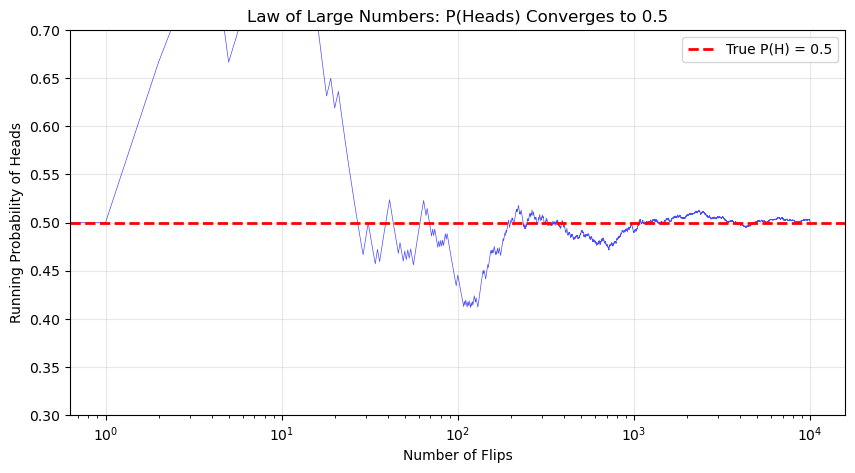

In [2]:
# ===============================================
# PROBABILITY THROUGH SIMULATION
# ===============================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("=" * 50)
print("LAW OF LARGE NUMBERS: Coin Flip Simulation")
print("=" * 50)

# Simulate coin flips
n_flips = 10000
flips = np.random.choice(['H', 'T'], size=n_flips)

# Calculate running probability of heads
heads_count = np.cumsum(flips == 'H')
running_prob = heads_count / np.arange(1, n_flips + 1)

print(f"\nAfter {n_flips} flips:")
print(f"  Heads: {np.sum(flips == 'H')}")
print(f"  Tails: {np.sum(flips == 'T')}")
print(f"  P(Heads) ≈ {np.mean(flips == 'H'):.4f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(running_prob, 'b-', alpha=0.7, linewidth=0.5)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='True P(H) = 0.5')
plt.xlabel('Number of Flips')
plt.ylabel('Running Probability of Heads')
plt.title('Law of Large Numbers: P(Heads) Converges to 0.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.3, 0.7)
plt.xscale('log')
plt.show()

---
# **Probability Math: Fundamental Rules**

## The Three Axioms of Probability (Kolmogorov)

1. **Non-negativity**: $P(A) \geq 0$ for any event A
2. **Normalization**: $P(S) = 1$ (sample space has probability 1)
3. **Additivity**: For mutually exclusive events: $P(A \cup B) = P(A) + P(B)$

## Key Probability Rules

| Rule | Formula |
|------|--------|
| **Complement** | $P(A') = 1 - P(A)$ |
| **Sum (General)** | $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ |
| **Sum (Mutually Exclusive)** | $P(A \cup B) = P(A) + P(B)$ |
| **Product (Independent)** | $P(A \cap B) = P(A) \cdot P(B)$ |
| **Product (General)** | $P(A \cap B) = P(A) \cdot P(B|A)$ |

In [3]:
# ===============================================
# PROBABILITY RULES IN ACTION
# ===============================================

from fractions import Fraction

print("=" * 50)
print("PROBABILITY RULES: Card Drawing Example")
print("=" * 50)

# Standard deck of 52 cards
total_cards = 52
hearts = 13
face_cards = 12  # J, Q, K in each suit
face_cards_hearts = 3  # J, Q, K of hearts

# P(Heart)
P_heart = Fraction(hearts, total_cards)
print(f"\n1. P(Heart) = {hearts}/{total_cards} = {P_heart}")

# P(Face Card)
P_face = Fraction(face_cards, total_cards)
print(f"2. P(Face Card) = {face_cards}/{total_cards} = {P_face}")

# P(Heart AND Face Card) - Intersection
P_heart_and_face = Fraction(face_cards_hearts, total_cards)
print(f"3. P(Heart ∩ Face) = {face_cards_hearts}/{total_cards} = {P_heart_and_face}")

# P(Heart OR Face Card) - Union (using addition rule)
P_heart_or_face = P_heart + P_face - P_heart_and_face
print(f"4. P(Heart ∪ Face) = P(H) + P(F) - P(H∩F)")
print(f"   = {P_heart} + {P_face} - {P_heart_and_face} = {P_heart_or_face}")

# Complement: P(NOT Heart)
P_not_heart = 1 - P_heart
print(f"\n5. P(Not Heart) = 1 - P(Heart) = {P_not_heart}")

PROBABILITY RULES: Card Drawing Example

1. P(Heart) = 13/52 = 1/4
2. P(Face Card) = 12/52 = 3/13
3. P(Heart ∩ Face) = 3/52 = 3/52
4. P(Heart ∪ Face) = P(H) + P(F) - P(H∩F)
   = 1/4 + 3/13 - 3/52 = 11/26

5. P(Not Heart) = 1 - P(Heart) = 3/4


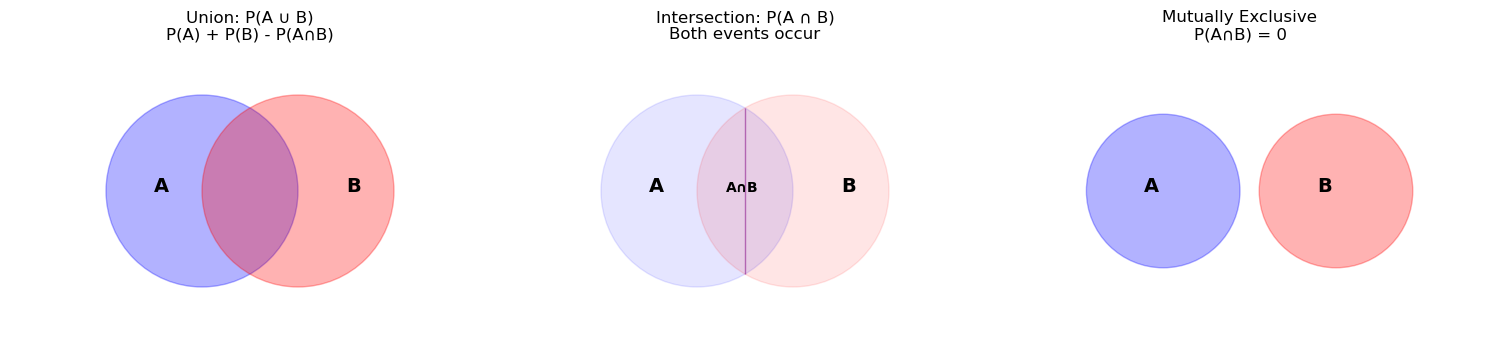

: 

In [ ]:
# ===============================================
# VISUALIZING PROBABILITY WITH VENN DIAGRAMS
# ===============================================

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Common setup
for ax in axes:
    ax.set_xlim(-2, 3)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')

# Plot 1: Union P(A ∪ B)
ax1 = axes[0]
c1 = Circle((0, 0), 1, fill=True, alpha=0.3, color='blue', label='A')
c2 = Circle((1, 0), 1, fill=True, alpha=0.3, color='red', label='B')
ax1.add_patch(c1)
ax1.add_patch(c2)
ax1.text(-0.5, 0, 'A', fontsize=14, fontweight='bold')
ax1.text(1.5, 0, 'B', fontsize=14, fontweight='bold')
ax1.set_title('Union: P(A ∪ B)\nP(A) + P(B) - P(A∩B)', fontsize=12)

# Plot 2: Intersection P(A ∩ B)
ax2 = axes[1]
c3 = Circle((0, 0), 1, fill=True, alpha=0.1, color='blue')
c4 = Circle((1, 0), 1, fill=True, alpha=0.1, color='red')
ax2.add_patch(c3)
ax2.add_patch(c4)
# Highlight intersection
theta = np.linspace(0, 2*np.pi, 100)
ax2.fill_between([0.5], [-0.866], [0.866], alpha=0.5, color='purple')
ax2.text(-0.5, 0, 'A', fontsize=14, fontweight='bold')
ax2.text(1.5, 0, 'B', fontsize=14, fontweight='bold')
ax2.text(0.3, 0, 'A∩B', fontsize=10, fontweight='bold')
ax2.set_title('Intersection: P(A ∩ B)\nBoth events occur', fontsize=12)

# Plot 3: Mutually Exclusive
ax3 = axes[2]
c5 = Circle((-0.3, 0), 0.8, fill=True, alpha=0.3, color='blue')
c6 = Circle((1.5, 0), 0.8, fill=True, alpha=0.3, color='red')
ax3.add_patch(c5)
ax3.add_patch(c6)
ax3.text(-0.5, 0, 'A', fontsize=14, fontweight='bold')
ax3.text(1.3, 0, 'B', fontsize=14, fontweight='bold')
ax3.set_title('Mutually Exclusive\nP(A∩B) = 0', fontsize=12)

plt.tight_layout()
plt.show()

---
## Summary

| Concept | Key Point |
|---------|----------|
| **Probability** | Measure of likelihood: P(A) ∈ [0, 1] |
| **Sample Space** | All possible outcomes |
| **Event** | Subset of sample space |
| **Complement** | P(A') = 1 - P(A) |
| **Union** | P(A ∪ B) = P(A) + P(B) - P(A ∩ B) |
| **Law of Large Numbers** | Relative frequency → true probability |